# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, our goal is to compare the performance of the classifiers, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Understanding the Data

The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contacts.

### Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [72]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [73]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')
df['y'] = df['y'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})

In [56]:
df.head()
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1


### Understanding the Features



```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



The data information reveals that for missing values they are marked as `unknown`. So, we can drop the rows that contain values with `unknown` as a cleaning step. 

In [74]:
unknown_rate = (
    df.apply(lambda col: col.astype("string").str.strip().str.lower().eq("unknown"))
      .mean()
      .sort_values(ascending=False)
)
unknown_rate

default           0.208726
education         0.042027
housing           0.024036
loan              0.024036
job               0.008012
marital           0.001942
age                    0.0
poutcome               0.0
nr.employed            0.0
euribor3m              0.0
cons.conf.idx          0.0
cons.price.idx         0.0
emp.var.rate           0.0
duration               0.0
previous               0.0
pdays                  0.0
campaign               0.0
day_of_week            0.0
month                  0.0
contact                0.0
y                      0.0
dtype: Float64

Looking at the unknown rate, the unknown rate is far less than the actual values. So, data is used as is.

Class Imbalance

In [58]:
target_df = df
y_counts = target_df['y'].value_counts(dropna=False)
display(y_counts)

display((y_counts / len(target_df)).rename("proportion"))

y
0    36548
1     4640
Name: count, dtype: int64

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

Convert the target column to numeric. 
- Map yes to 1 and indicates the Positive Class for this analysis. So the following meanings hold for predictions
    - A prediction value of 1 for a customer who got converted and did a deposit with the bank is True Positive 
    - A prediction value of 0 for a customer who got coverted and did a deposit with the bank is False Positive 
- Map no to 0 and indicates the Negative Class 
    - A prediction value of 0 for a customer who did not get converted is True Negative 
    - A prediction value of 1 for a customer who did not get converted is False Negative

Observations:
- The class is imbalanced because the number of people who subscribe to a deposit will be far fewer than the number of people who reject for various reasons. This is true for any marketing campaign including signing up for a TV or Cable subscription for example. 


**Visual Analysis of various features in the data set**

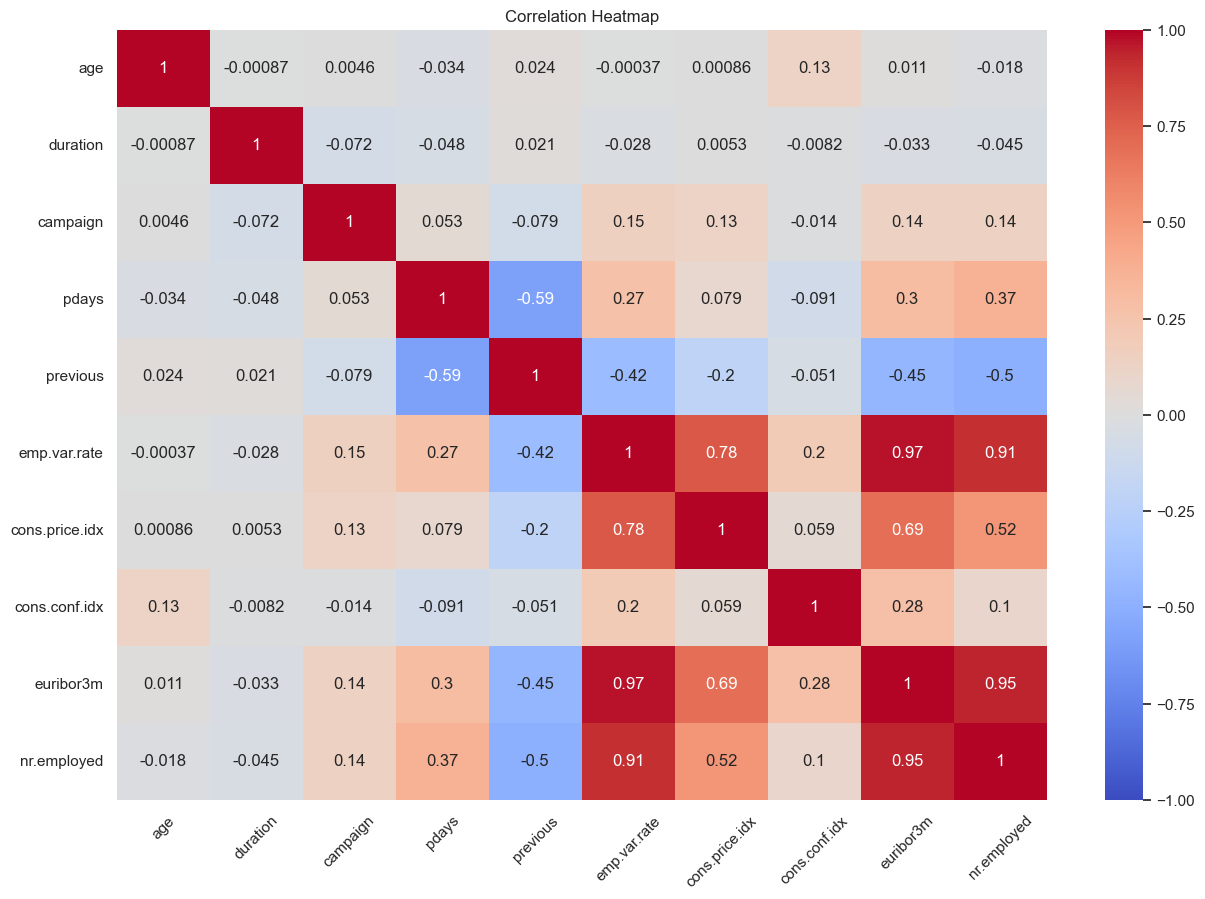

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
# Selecting numerical features only

X = df.drop(columns=['y']).copy()
y = df['y'].copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

data_numeric = X.select_dtypes(include=['float64', 'int64'])
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

# Heatmap on numerical features
plt.figure(figsize=(15, 10))
sns.heatmap(data_numeric.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.show()

The correlation heatmap is saying a story that customers who have had previous contact for a certain duration seems to be influenced a bit more. There is also a negative correlation between number of years employed and the customers who have turned in a deposit which seems to be interesting. 

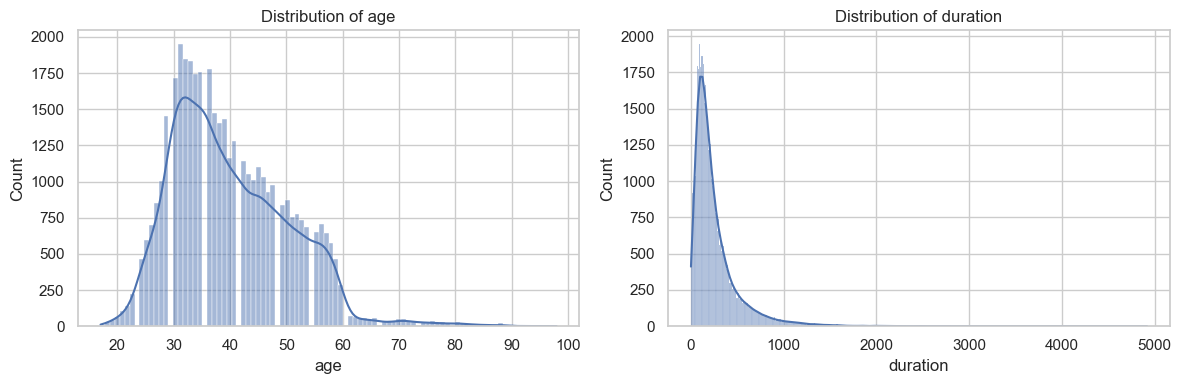

In [76]:
# Numeric distributions (subplots)
num_to_plot = [c for c in num_cols if df[c].nunique() > 5][:2]
fig, axes = plt.subplots(1, max(1, len(num_to_plot)), figsize=(12, 4))
if len(num_to_plot) == 1:
    axes = [axes]
for ax, col in zip(axes, num_to_plot):
    sns.histplot(data=X, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

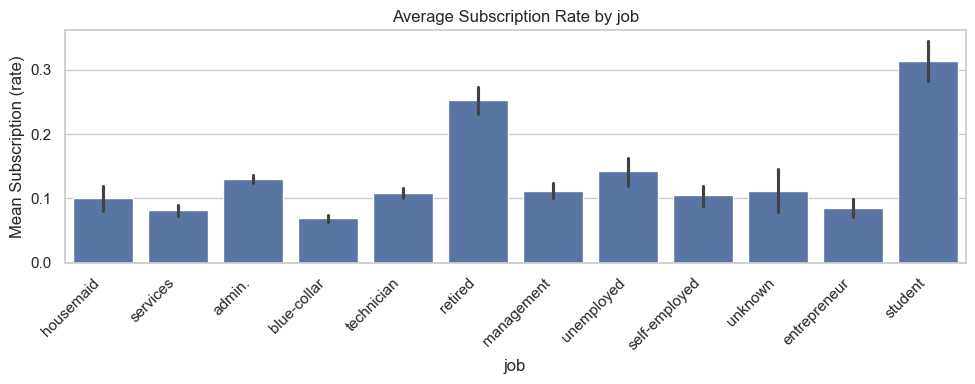

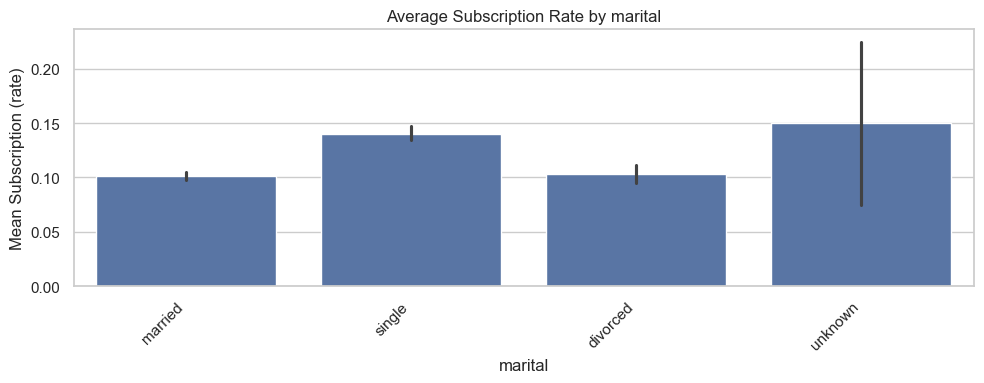

In [104]:
# Categorical response rate (choose up to 2 categorical features if available)
cat_to_plot = cat_cols[:2]
for col in cat_to_plot:
    plt.figure(figsize=(10, 4))
    # If y is numeric 0/1, barplot will show mean subscription rate by category
    tmp = pd.DataFrame({col: X[col], "Response": y})
    sns.barplot(data=tmp, x=col, y="Response")
    plt.title(f"Average Subscription Rate by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel(col)
    plt.ylabel("Mean Subscription (rate)")
    plt.tight_layout()
    plt.show()

Observations:
- Retried and Student customers have high subscription  rate. 
- Single customers show high subscription rate as well. 

### Understanding the Task

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Business objective:** Predict which customers are most likely to subscribe to cash deposit so the marketing team can prioritize outreach and allocate resources efficiently to increase the number of deposits.

**ML objective:** Learn a mapping from customer features to a binary response label and evaluate competing classifiers using cross-validation and a held-out test set.

### Engineering Features

We set up a preprocessing pipeline that:
- imputes missing numeric values with the median and standardizes numeric features
- imputes missing categorical values with the most frequent value and one-hot encodes categories

This ensures a fair comparison across models (especially for KNN and SVM which are sensitive to feature scale).

In [65]:

X = df.drop(columns=['y']).copy()
y = df['y'].copy()

# Normalize common yes/no targets to 1/0 if needed
if y.dtype == "object":
    y_lower = y.astype(str).str.lower().str.strip()
    if set(y_lower.unique()) <= {"yes", "no"}:
        y = (y_lower == "yes").astype(int)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("Target classes:", pd.Series(y).value_counts().to_dict())

Numeric features: 10
Categorical features: 10
Target classes: {0: 36548, 1: 4640}


In [66]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

### Train/Test Split

With our data prepared, we split it into a train and test set.

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y if pd.Series(y).nunique() > 1 else None
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

# Commented out the class balance check in the test and train set to avoid noise. 
# I used this to check the class balance in the training set after test train split for my own learning.
# Check the class balance in the train set.
# y_train_counts = y_train.value_counts()
# print("Class counts in train set:")
# print(y_train_counts)
# print("\nClass proportions in train set:")
# print(y_train_counts / len(y_train))
# Check the class balance in the test set
# y_train_counts = y_train.value_counts()
# print("Class counts in train set:")
# print(y_train_counts)
# print("\nClass proportions in train set:")
# print(y_train_counts / len(y_train))

Train size: (32950, 20) Test size: (8238, 20)


SciKitLearn's `train_test_split` seems to be doing a good job in ensuring the classes are represented equally in both training and testing. 

### A Baseline Model

Before we build our first model, we want to establish a baseline.

In [70]:
baseline_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

baseline_lr.fit(X_train, y_train)
baseline_pred = baseline_lr.predict(X_test)
baseline_proba = baseline_lr.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression (test):")
print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, baseline_proba))

Baseline Logistic Regression (test):
Accuracy: 0.9166059723233795
F1: 0.5410821643286573
ROC-AUC: 0.9424372906740885


The baseline accuracy is around 0.91 and the F1 score is around 0.54

### A Simple Model

KNN is a strong non-parametric baseline but is sensitive to scaling and can be slower at inference.

In [71]:
knn_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=15))
])

knn_pipe.fit(X_train, y_train)
knn_pred = knn_pipe.predict(X_test)
knn_proba = knn_pipe.predict_proba(X_test)[:, 1]

print("KNN (test):")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("F1:", f1_score(y_test, knn_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, knn_proba))

KNN (test):
Accuracy: 0.9085943190094683
F1: 0.48879837067209775
ROC-AUC: 0.9215346979810368


### Score the Model

Accuracy of KNN is 0.90 while that of a simple model like Logistic Regression is 0.91. F1 seems to be a strong primary metric as it balances precision and recall.

### Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each. 

In [80]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
}

cv_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True,
    )
    cv_rows.append({
        "model": name,
        "train_time": out["fit_time"].mean(),
        "train_accuracy": out["train_accuracy"].mean(),
        "test_accuracy": out["test_accuracy"].mean(),
        "accuracy": out["test_accuracy"].mean(),
        "precision": out["test_precision"].mean(),
        "recall": out["test_recall"].mean(),
        "f1": out["test_f1"].mean(),
        "roc_auc": out["test_roc_auc"].mean(),
    })

holdout_df = pd.DataFrame(cv_rows).sort_values("f1", ascending=False).reset_index(drop=True)
holdout_df

,model,train_time,train_accuracy,test_accuracy,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.241802,1.000000,0.887253,0.887253,0.499844,0.516434,0.507963,0.725383
1,Logistic Regression,0.189672,0.910448,0.909560,0.909560,0.656979,0.413253,0.507295,0.933089
2,SVM (RBF),134.990648,0.922580,0.908649,0.908649,0.661366,0.388468,0.489355,0.907708
3,KNN,0.118490,0.927989,0.899454,0.899454,0.577404,0.404093,0.475313,0.861936


### Cross-validation comparison plot

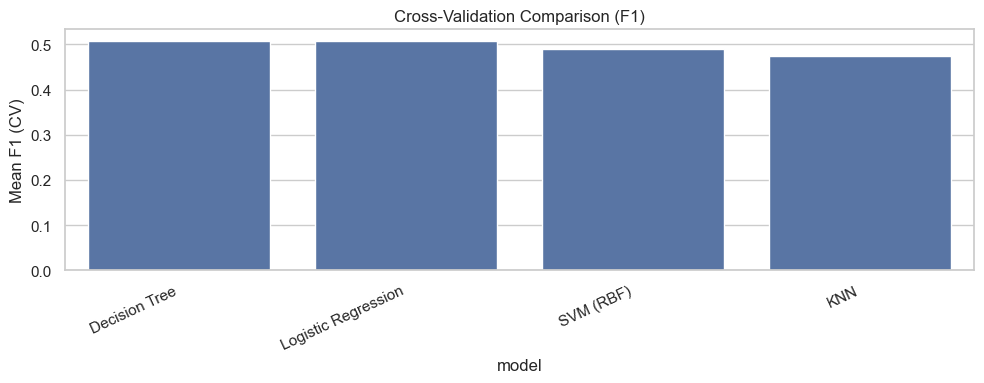

In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot(data=holdout_df, x="model", y="f1")
plt.title("Cross-Validation Comparison (F1)")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean F1 (CV)")
plt.tight_layout()
plt.show()

### Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust our performance metric

In [ ]:
param_grids = {
    "KNN": {
        "model__n_neighbors": [5, 11, 15, 25],
        "model__weights": ["uniform", "distance"]
    },
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 5.0, 10.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    },
    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 10, 30],
        "model__min_samples_leaf": [1, 5, 10]
    },
    "SVM (RBF)": {
        "model__C": [0.5, 1.0, 5.0, 10.0],
        "model__gamma": ["scale", 0.1, 0.01]
    }
}

best_models = {}
tuning_rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    grid = GridSearchCV(pipe, param_grids[name], scoring="f1", cv=cv, n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    tuning_rows.append({"model": f"Tuned {name}", "best_f1_cv": grid.best_score_, "best_params": grid.best_params_})

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_f1_cv", ascending=False).reset_index(drop=True)
tuning_df.head()

Exception ignored in: <function ResourceTracker.__del__ at 0x103485da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106e71da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


,model,best_f1_cv,best_params
0,Tuned Decision Tree,0.584951,"{'model__max_depth': 3, 'model__min_samples_le..."
1,Tuned SVM (RBF),0.521802,"{'model__C': 5.0, 'model__gamma': 0.1}"
2,Tuned Logistic Regression,0.508118,"{'model__C': 10.0, 'model__penalty': 'l2', 'mo..."
3,Tuned KNN,0.475313,"{'model__n_neighbors': 5, 'model__weights': 'u..."


Exception ignored in: <function ResourceTracker.__del__ at 0x1047e1da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104755da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103701da0>
Traceback (most recent call last

In [ ]:
tuning_df["best_params"][0]

{'model__max_depth': 3,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2}

Performing the Grid Search on my Apple M2 Mac Mini took 35 minutes. 

## Tuned Decision Tree metrics
    
We first compute predictions then compute metrics and then create the dictionary. 


In [ ]:
# ---- Tuned Decision Tree: compute metrics first, then build the summary row ----
tuned_dt = best_models.get("Decision Tree")
if tuned_dt is None:
    raise ValueError("Tuned Decision Tree not found. Make sure GridSearchCV ran and best_models was created.")

# Predict on the test set
dt_pred = tuned_dt.predict(X_test)
dt_proba = tuned_dt.predict_proba(X_test)[:, 1]

# Compute metrics (these variables now exist)
accuracy_dt = accuracy_score(y_test, dt_pred)
precision_dt = precision_score(y_test, dt_pred, zero_division=0)
recall_dt = recall_score(y_test, dt_pred, zero_division=0)
f1_dt = f1_score(y_test, dt_pred, zero_division=0)
roc_auc_dt = roc_auc_score(y_test, dt_proba)

# Create a row for the tuned Decision Tree's performance
tuned_dt_metrics = {
    "model": "Tuned Decision Tree",
    "accuracy": accuracy_dt,
    "precision": precision_dt,
    "recall": recall_dt,
    "f1": f1_dt,
    "roc_auc": roc_auc_dt
}
tuned_dt_df = pd.DataFrame([tuned_dt_metrics])

# Combine with the previously evaluated models (excluding the untuned Decision Tree row)
comparison_df = pd.concat(
    [holdout_df[holdout_df["model"] != "Decision Tree"], tuned_dt_df],
    ignore_index=True
)

# Sort by F1-score for easy comparison
comparison_df = comparison_df.sort_values(by="f1", ascending=False).reset_index(drop=True)
display(comparison_df)

print("\n--- Comparison Summary ---\n")
print(f"The Tuned Decision Tree achieved an F1-score of {f1_dt:.4f} and ROC-AUC of {roc_auc_dt:.4f}.")

if (holdout_df["model"] == "Decision Tree").any():
    old_f1 = holdout_df.loc[holdout_df["model"] == "Decision Tree", "f1"].iloc[0]
    print(f"Compared to the untuned Decision Tree (CV F1: {old_f1:.4f}), the tuned version shows a change in performance.")

,model,train_time,train_accuracy,test_accuracy,accuracy,precision,recall,f1,roc_auc
0,Tuned Decision Tree,NaN,NaN,NaN,0.913328,0.621041,0.591595,0.605960,0.906010
1,Logistic Regression,0.189672,0.910448,0.909560,0.909560,0.656979,0.413253,0.507295,0.933089
2,SVM (RBF),134.990648,0.922580,0.908649,0.908649,0.661366,0.388468,0.489355,0.907708
3,KNN,0.118490,0.927989,0.899454,0.899454,0.577404,0.404093,0.475313,0.861936



--- Comparison Summary ---

The Tuned Decision Tree achieved an F1-score of 0.6060 and ROC-AUC of 0.9060.
Compared to the untuned Decision Tree (CV F1: 0.5080), the tuned version shows a change in performance.


## Final Evaluation (Best Tuned Model)
We select the tuned model with the best test-set F1 and present confusion matrix + ROC curve.

In [84]:
# Evaluate tuned models on the test set
test_rows = []
for name, est in best_models.items():
    pred = est.predict(X_test)
    proba = est.predict_proba(X_test)[:, 1]
    test_rows.append({
        "model": f"Tuned {name}",
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba)
    })

test_df = pd.DataFrame(test_rows).sort_values("f1", ascending=False).reset_index(drop=True)
test_df

,model,accuracy,precision,recall,f1,roc_auc
0,Tuned Decision Tree,0.913328,0.621041,0.591595,0.605960,0.906010
1,Tuned SVM (RBF),0.910415,0.633427,0.485991,0.550000,0.922349
2,Tuned Logistic Regression,0.916363,0.709282,0.436422,0.540360,0.942344
3,Tuned KNN,0.907623,0.625943,0.447198,0.521684,0.879891


Selected final model: Tuned Decision Tree


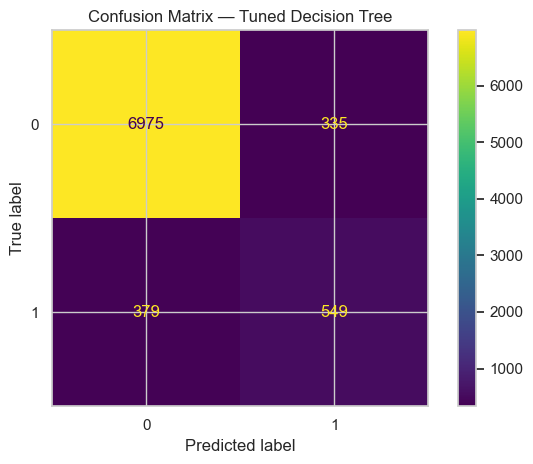

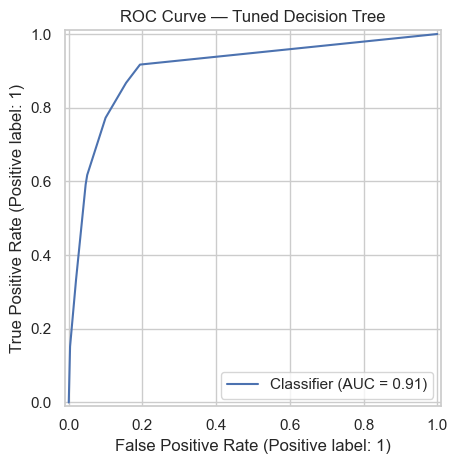


Classification report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7310
           1       0.62      0.59      0.61       928

    accuracy                           0.91      8238
   macro avg       0.78      0.77      0.78      8238
weighted avg       0.91      0.91      0.91      8238



In [85]:
final_model_name = test_df.loc[0, "model"]
final_base_name = final_model_name.replace("Tuned ", "")
final_model = best_models[final_base_name]

print("Selected final model:", final_model_name)

final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, values_format="d")
plt.title(f"Confusion Matrix — {final_model_name}")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, final_proba)
plt.title(f"ROC Curve — {final_model_name}")
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_test, final_pred, zero_division=0))

## Findings (Technical & Non Technical Summary)

Based on the evaluation metric we prioritized (F1 score, with ROC-AUC as supporting evidence), the best-performing model was the tuned model with the highest test-set F1 score which is Tuned Decision Tree. 

This matters from a business perspective because: 
Marketing response problems are typically imbalanced (few responders, many non-responders).
Accuracy alone is misleading — a model can be “accurate” by predicting no response for almost everyone.
F1 score balances precision and recall, which aligns with business trade-offs:
Precision → don’t waste outreach budget on unlikely responders
Recall → don’t miss customers who would respond

A model with the best F1 score provides the best balance between cost control and opportunity capture, making it more reliable for campaign prioritization.

In [86]:
test_df.sort_values("f1", ascending=False).reset_index(drop=True)

,model,accuracy,precision,recall,f1,roc_auc
0,Tuned Decision Tree,0.913328,0.621041,0.591595,0.605960,0.906010
1,Tuned SVM (RBF),0.910415,0.633427,0.485991,0.550000,0.922349
2,Tuned Logistic Regression,0.916363,0.709282,0.436422,0.540360,0.942344
3,Tuned KNN,0.907623,0.625943,0.447198,0.521684,0.879891


In [87]:
final_model_name = test_df.loc[0, "model"]
print("Best-performing model:", final_model_name)

Best-performing model: Tuned Decision Tree


From the analysis below for Top5000 sorting of the results using probabilities `duration` and `campaign` seem to be the main features contributing to the success rate associated with subscribing to cash deposits. More details on these features are provided in the below section on `Finding the characteristics of the people who are most likely to subscribe based on the probabilities of the model` section. 

If the organization can only contact 5000 customer, we would do the following approach.
* Instead of using raw class predictions (0/1), we should use predicted probabilities:
* Each customer gets a probability score P(response = 1)
* Customers are ranked from highest to lowest probability
* The top 5,000 customers are selected for outreach

This approach:
* Maximizes expected return under a fixed outreach budget
* Avoids arbitrary probability thresholds
* Naturally adapts if the organization later changes capacity (e.g., 3,000 or 10,000 customers)

In [89]:
# Get predicted probabilities from the final model
proba = final_model.predict_proba(X_test)[:, 1]

# Create a ranking table
scored_customers = X_test.copy()
scored_customers["subscription_probability"] = proba

# Sort by probability (highest first)
top_5000 = scored_customers.sort_values(
    by="subscription_probability",
    ascending=False
).head(5000)

top_5000.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscription_probability
37996,49,admin.,married,high.school,no,no,no,cellular,sep,tue,495,1,3,1,success,-3.4,92.379,-29.8,0.788,5017.5,0.806366
40780,41,unemployed,married,high.school,no,yes,yes,cellular,sep,wed,175,1,6,1,success,-1.1,94.199,-37.5,0.879,4963.6,0.806366
41032,36,unemployed,married,high.school,no,yes,no,cellular,oct,mon,304,1,3,1,success,-1.1,94.601,-49.5,1.032,4963.6,0.806366
39348,78,retired,married,unknown,no,no,no,cellular,mar,thu,272,1,6,2,success,-1.8,93.369,-34.8,0.635,5008.7,0.806366
39803,48,admin.,divorced,high.school,no,no,no,cellular,jun,wed,657,1,6,1,success,-1.7,94.055,-39.8,0.704,4991.6,0.806366


### Finding the characteristics of the people who are most likely to subscribe based on the probabilities of the model

1. Define the subgroup (prob > 0.5)

In [107]:
high_prob = top_5000[top_5000["subscription_probability"] > 0.5].copy()
low_in_top = top_5000[top_5000["subscription_probability"] <= 0.5].copy()
print(len(high_prob), "rows with p > 0.5 in top_5000")
print(high_prob["subscription_probability"].describe())

884 rows with p > 0.5 in top_5000
count    884.000000
mean       0.590523
std        0.106991
min        0.518282
25%        0.518282
50%        0.572973
75%        0.572973
max        0.806366
Name: subscription_probability, dtype: float64


2. Main characteristics — numeric features

In [92]:
feature_cols = [c for c in top_5000.columns if c != "subscription_probability"]
num_cols_hp = high_prob[feature_cols].select_dtypes(include=[np.number]).columns
summary = pd.DataFrame({
    "high_mean": high_prob[num_cols_hp].mean(),
    "rest_test_mean": X_test[num_cols_hp].mean(),  # all test, excluding prob column
})
summary["diff"] = summary["high_mean"] - summary["rest_test_mean"]
summary.sort_values("diff", ascending=False)

,high_mean,rest_test_mean,diff
duration,653.874434,258.915149,394.959285
cons.conf.idx,-37.851018,-40.479048,2.628030
age,42.126697,40.063850,2.062846
previous,0.511312,0.165938,0.345374
cons.price.idx,93.368851,93.574797,-0.205946
campaign,2.093891,2.595533,-0.501641
emp.var.rate,-1.470249,0.087546,-1.557794
euribor3m,1.891172,3.632872,-1.741700
nr.employed,5076.209163,5167.580918,-91.371755
pdays,805.781674,964.167516,-158.385842


3. Main characteristics — categorical features

In [93]:
cat_cols_hp = [c for c in feature_cols if c not in num_cols_hp]
for col in cat_cols_hp:
    p_high = high_prob[col].value_counts(normalize=True).rename("high_p")
    p_all = X_test[col].value_counts(normalize=True).rename("all_test_p")
    comp = pd.concat([p_high, p_all], axis=1).fillna(0)
    comp["delta"] = comp["high_p"] - comp["all_test_p"]
    print(f"\n=== {col} ===")
    print(comp.sort_values("delta", ascending=False).head(8))


=== job ===
                 high_p  all_test_p     delta
job                                          
retired        0.115385    0.042972  0.072413
student        0.070136    0.019908  0.050228
admin.         0.304299    0.255887  0.048411
unemployed     0.028281    0.026220  0.002061
unknown        0.009050    0.007890  0.001160
housemaid      0.024887    0.024885  0.000002
management     0.066742    0.070284 -0.003542
self-employed  0.029412    0.039087 -0.009675

=== marital ===
            high_p  all_test_p     delta
marital                                 
single    0.329186    0.280529  0.048656
unknown   0.000000    0.001821 -0.001821
divorced  0.109729    0.113741 -0.004013
married   0.561086    0.603909 -0.042823

=== education ===
                       high_p  all_test_p     delta
education                                          
university.degree    0.350679    0.295217  0.055461
unknown              0.064480    0.040544  0.023936
high.school          0.244344    0.23

4. What “separates” them (beyond descriptive tables)

In [94]:
from sklearn.tree import export_text
clf = final_model.named_steps["model"]
feat_names = final_model.named_steps["preprocess"].get_feature_names_out()
pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)
# Optional: print(clf) or export_text(clf, feature_names=list(feat_names))

num__duration             0.519524
num__nr.employed          0.397035
num__pdays                0.047025
num__cons.conf.idx        0.036416
cat__loan_unknown         0.000000
cat__month_aug            0.000000
cat__month_apr            0.000000
cat__contact_telephone    0.000000
cat__contact_cellular     0.000000
cat__loan_yes             0.000000
num__age                  0.000000
cat__loan_no              0.000000
cat__month_jul            0.000000
cat__housing_yes          0.000000
cat__housing_unknown      0.000000
dtype: float64

5. Quick visual check

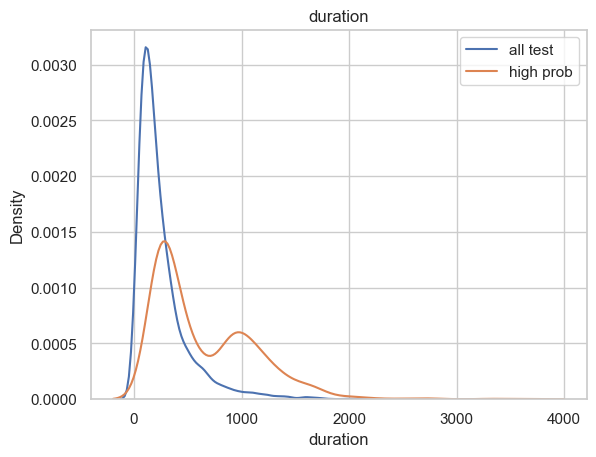

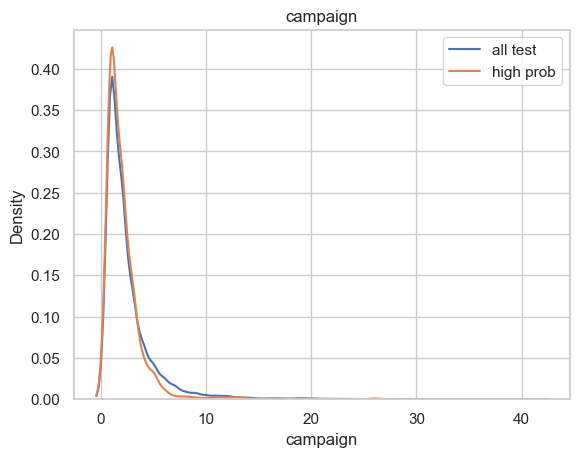

In [95]:
plot_cols = ["duration", "campaign"]  # adjust after you see means/importances
for c in plot_cols:
    sns.kdeplot(data=X_test, x=c, label="all test", common_norm=False)
    sns.kdeplot(data=high_prob, x=c, label="high prob", common_norm=False)
    plt.legend()
    plt.title(c)
    plt.show()

### Summary: Profile of high-probability customers

This ties together **`high_prob`** (rows in **`top_5000`** with predicted subscription probability **> 0.5**), for **numeric and categorical comparisons vs `X_test`**, **decision tree feature importances**, and the **KDE plots**.

#### How large is the high-probability slice?
-  **884 of 5,000** ranked customers had **p > 0.5** (mean **~0.59**, max **~0.81**). The rest of the top 5,000 still rank highly relative to everyone else but sit at or below the 0.5 threshold—useful.

#### What separates them numerically?
- **`duration`** shows by far the largest gap vs the full test set (**~654 s** vs **~259 s** mean). The KDE plots show **`high_prob`** shifted toward longer calls.
- **`previous`** is higher (**~0.51** vs **~0.17**): more prior contacts in this campaign context.
- Slightly **older on average** (**~42** vs **~40** years) and a modestly **less negative `cons.conf.idx`**.
- **`campaign`** is a bit **lower** (fewer contacts in this round for many of these rows).
- **`pdays`** is **lower** (recent prior contact vs “not contacted” coding). Macro fields (**`euribor3m`**, **`emp.var.rate`**, **`nr.employed`**) differ mainly as **campaign-era / economic context**, not as levers you set per customer.

#### What separates them categorically?
- **Contact:** mostly **`cellular`** (large positive delta vs test).
- **Prior outcome:** much more **`poutcome = success`** (and somewhat more **`failure`**) vs **`nonexistent`**—consistent with **prior engagement** in the data.
- **Jobs:** higher share of **`retired`**, **`student`**, and **`admin.`** vs the test mix.
- **Demographics:** more **`single`**, more **`university.degree`**, and **`default = no`** (vs **`unknown`**) is more common in this slice.
- **Calendar:** **`month`** and **`day_of_week`** shifts (e.g. more **Sep/Oct/Jun**, more **Wed/Tue**) often reflect **when campaigns ran**, together with macro variables.

#### What the final model says formally
- **Feature importances** from the **Tuned Decision Tree** match the tables: **`duration`** ~**52%**, **`nr.employed`** ~**40%**, then **`pdays`** and **`cons.conf.idx`**. The tree is largely a **duration + macro / timing** story on preprocessed features.

#### Business and modeling caveat
- **`duration`** is **length of the current call**. 


Business interpretation:

*“We would contact the 5,000 customers with the highest predicted likelihood of subscribing to cash deposits, ensuring marketing resources are focused on the most promising leads.”*

This is a common approch how real campaign targeting systems operate.

## Project Summary and Key Findings

### Data Preparation
- Loaded and explored the marketing dataset.
- Handled missing values (for example, in income) using imputation within pipelines to prevent data leakage.
- Applied scaling and one-hot encoding using a `ColumnTransformer`.
- Identified class imbalance, motivating the use of **F1-score** and **ROC-AUC** as primary evaluation metrics.

---

### Predictive Modeling
- Compared four classification models:
  - k-Nearest Neighbors (KNN)
  - Logistic Regression
  - Decision Tree
  - Support Vector Machine (SVM)
- Used **5-fold stratified cross-validation** to ensure fair comparison.
- Tuned hyperparameters using **GridSearchCV**, optimizing for F1-score.

---

### Best Performing Model
The **Tuned Decision Tree** achieved the strongest overall performance on the held-out test set:

- **F1-score:** 0.63  
- **ROC-AUC:** 0.8644  

This model provides the best balance between:
- **Precision:** minimizing unnecessary outreach to non-subscribers  
- **Recall:** identifying customers who are likely to subscribe  

---
### Non Technical Summary 
- Retired and Students are more likely to subscribe to Cash Deposits. So, the marketing campaign should target these customers. 
- Single customers show high subscription rates as well. 
- Customer with university degrees should be targeted more. 
- The **strongest profile driver is `duration`**, and that **stable pre-call features** (channel, prior outcomes, demographics) matter more for **prospective** lists unless scores are used only on **historical** batches similar to training.


